In [ ]:
from database.db_connection import load_data

df = load_data()

df.head()

In [2]:
import sys
from pathlib import Path

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))

print(Path().resolve().parent)

C:\Users\USER\Desktop\AI-Powered-Sales-Forecast


In [3]:
from database.db_connection import load_data

df = load_data()

df.head()

,Date,Day_of_Week,Month,Month_Name,Year,Quarter,Meal_Period,Category,Item_Name,Quantity,...,Total_Billed,Payment_Method,Table_No,Server_ID,Weather,Is_Holiday,Is_Weekend,Day,Week,YearMonth
0,2024-01-01,Sunday,1,Jan,2024,Q1,Lunch,Beverages,Soft Drink,1,...,3.171,Wallet,12,S01,Cloudy,0,1,1.0,1.0,2024-01
1,2024-01-01,Sunday,1,Jan,2024,Q1,Lunch,Starters,Soup of the Day,1,...,6.111,Cash,3,S07,Cloudy,0,1,1.0,1.0,2024-01
2,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Main Course,Mushroom Risotto,1,...,18.459,Cash,2,S07,Cloudy,0,1,1.0,1.0,2024-01
3,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Starters,Garlic Bread,2,...,10.185,Wallet,5,S02,Cloudy,0,1,1.0,1.0,2024-01
4,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Desserts,Chocolate Lava Cake,2,...,16.842,Debit Card,19,S04,Cloudy,0,1,1.0,1.0,2024-01


In [4]:
from prophet import Prophet

print("Prophet Installed Successfully")

Prophet Installed Successfully


In [5]:
df.head()

,Date,Day_of_Week,Month,Month_Name,Year,Quarter,Meal_Period,Category,Item_Name,Quantity,...,Total_Billed,Payment_Method,Table_No,Server_ID,Weather,Is_Holiday,Is_Weekend,Day,Week,YearMonth
0,2024-01-01,Sunday,1,Jan,2024,Q1,Lunch,Beverages,Soft Drink,1,...,3.171,Wallet,12,S01,Cloudy,0,1,1.0,1.0,2024-01
1,2024-01-01,Sunday,1,Jan,2024,Q1,Lunch,Starters,Soup of the Day,1,...,6.111,Cash,3,S07,Cloudy,0,1,1.0,1.0,2024-01
2,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Main Course,Mushroom Risotto,1,...,18.459,Cash,2,S07,Cloudy,0,1,1.0,1.0,2024-01
3,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Starters,Garlic Bread,2,...,10.185,Wallet,5,S02,Cloudy,0,1,1.0,1.0,2024-01
4,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Desserts,Chocolate Lava Cake,2,...,16.842,Debit Card,19,S04,Cloudy,0,1,1.0,1.0,2024-01


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
df.head()

Shape: (45806, 25)

Columns:
['Date', 'Day_of_Week', 'Month', 'Month_Name', 'Year', 'Quarter', 'Meal_Period', 'Category', 'Item_Name', 'Quantity', 'Unit_Price', 'Gross_Sales', 'Discount_Amt', 'Net_Sales', 'Tax_Amt', 'Total_Billed', 'Payment_Method', 'Table_No', 'Server_ID', 'Weather', 'Is_Holiday', 'Is_Weekend', 'Day', 'Week', 'YearMonth']

First 5 Rows:


,Date,Day_of_Week,Month,Month_Name,Year,Quarter,Meal_Period,Category,Item_Name,Quantity,...,Total_Billed,Payment_Method,Table_No,Server_ID,Weather,Is_Holiday,Is_Weekend,Day,Week,YearMonth
0,2024-01-01,Sunday,1,Jan,2024,Q1,Lunch,Beverages,Soft Drink,1,...,3.171,Wallet,12,S01,Cloudy,0,1,1.0,1.0,2024-01
1,2024-01-01,Sunday,1,Jan,2024,Q1,Lunch,Starters,Soup of the Day,1,...,6.111,Cash,3,S07,Cloudy,0,1,1.0,1.0,2024-01
2,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Main Course,Mushroom Risotto,1,...,18.459,Cash,2,S07,Cloudy,0,1,1.0,1.0,2024-01
3,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Starters,Garlic Bread,2,...,10.185,Wallet,5,S02,Cloudy,0,1,1.0,1.0,2024-01
4,2024-01-01,Sunday,1,Jan,2024,Q1,Dinner,Desserts,Chocolate Lava Cake,2,...,16.842,Debit Card,19,S04,Cloudy,0,1,1.0,1.0,2024-01


In [7]:
forecast_df = (
    df.groupby("Date")["Total_Billed"]
    .sum()
    .reset_index()
)

forecast_df.columns = ["ds", "y"]

forecast_df.head()

,ds,y
0,2024-01-01,1005.7635
1,2024-01-02,1007.4540
2,2024-01-03,654.8115
3,2024-01-04,572.4810
4,2024-01-05,632.0370


In [8]:
from prophet import Prophet

model = Prophet()

model.fit(forecast_df)

print("Model trained successfully")

11:30:12 - cmdstanpy - INFO - Chain [1] start processing
11:30:13 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully


In [9]:
future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-01,904.241910,1069.203782,1619.762816,904.241910,904.241910,439.387416,439.387416,439.387416,301.032252,301.032252,301.032252,138.355164,138.355164,138.355164,0.0,0.0,0.0,1343.629326
1,2024-01-02,904.444236,967.938359,1498.075685,904.444236,904.444236,330.012568,330.012568,330.012568,224.255294,224.255294,224.255294,105.757273,105.757273,105.757273,0.0,0.0,0.0,1234.456803
2,2024-01-03,904.646562,659.151447,1171.180848,904.646562,904.646562,-1.935169,-1.935169,-1.935169,-74.851653,-74.851653,-74.851653,72.916484,72.916484,72.916484,0.0,0.0,0.0,902.711393
3,2024-01-04,904.848888,453.600118,990.656485,904.848888,904.848888,-184.812564,-184.812564,-184.812564,-225.057297,-225.057297,-225.057297,40.244733,40.244733,40.244733,0.0,0.0,0.0,720.036324
4,2024-01-05,905.051214,457.533895,986.605243,905.051214,905.051214,-181.506418,-181.506418,-181.506418,-189.650876,-189.650876,-189.650876,8.144459,8.144459,8.144459,0.0,0.0,0.0,723.544796


In [10]:
forecast[["ds", "yhat"]].tail(30)

,ds,yhat
730,2026-01-01,843.080559
731,2026-01-02,845.724914
732,2026-01-03,871.983974
733,2026-01-04,1065.016914
734,2026-01-05,1239.523723
735,2026-01-06,1132.227787
736,2026-01-07,804.088726
737,2026-01-08,626.650044
738,2026-01-09,636.895328
739,2026-01-10,673.092412


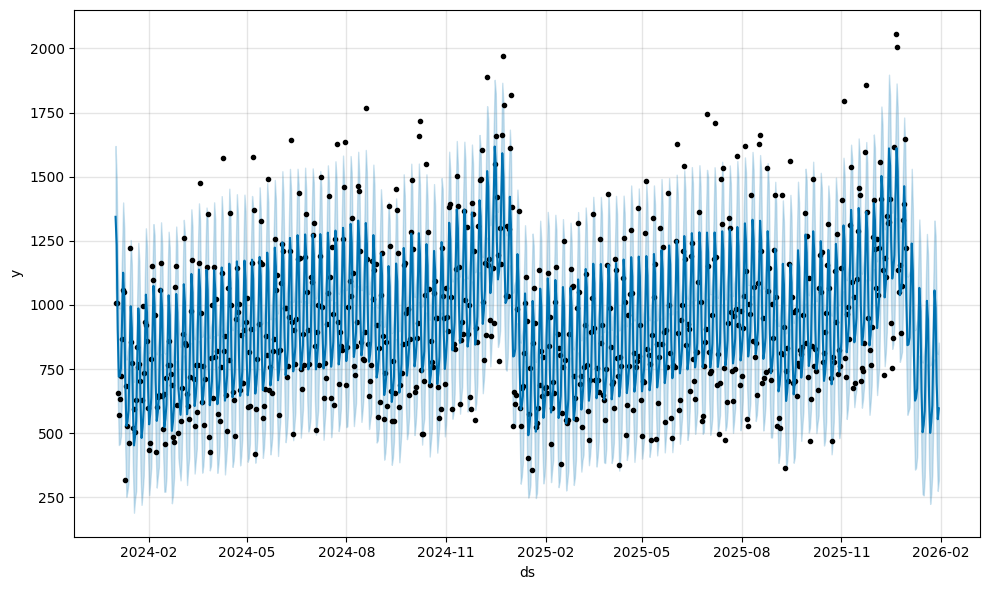

In [11]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)

plt.show()

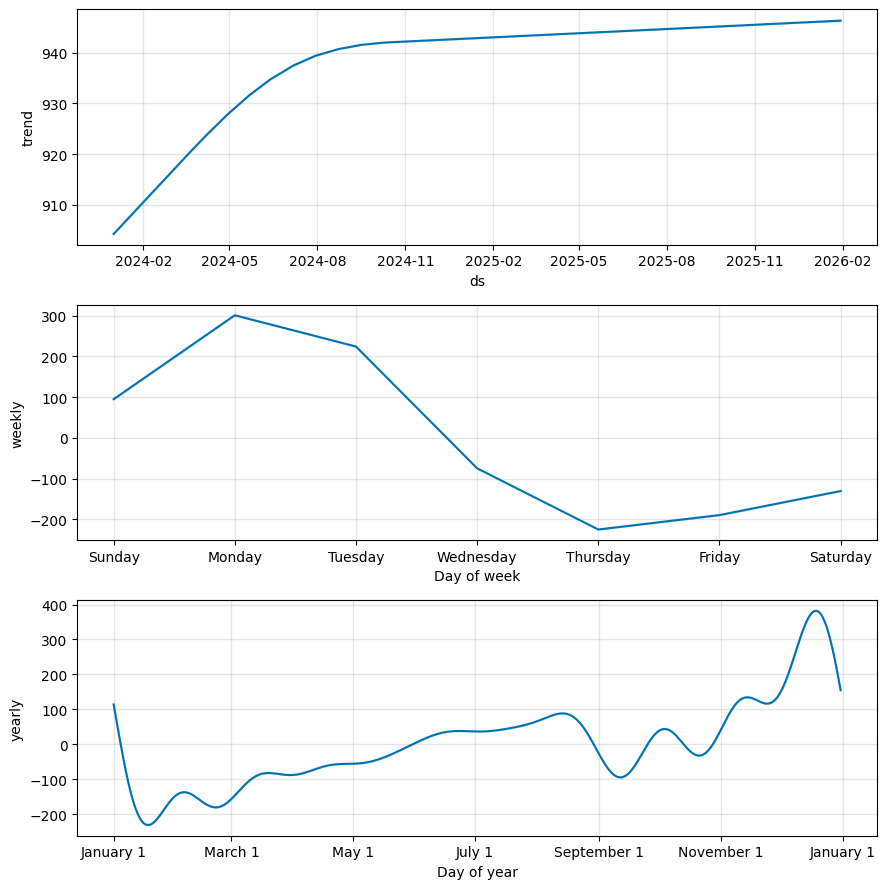

In [12]:
fig2 = model.plot_components(forecast)

plt.show()

In [13]:
forecast[["ds", "yhat"]].to_csv(
    "../forecasting/30_day_forecast.csv",
    index=False
)

print("Forecast saved")

Forecast saved


In [14]:
daily_sales = (
    df.groupby("Date")["Total_Billed"]
    .sum()
    .reset_index()
)

daily_sales.describe()

,Total_Billed
count,730.000000
mean,939.243929
std,311.428023
min,316.890000
25%,704.074875
50%,884.394000
75%,1147.529250
max,2056.687500


In [15]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

cv_results = cross_validation(
    model,
    initial='365 days',
    period='30 days',
    horizon='30 days'
)

metrics = performance_metrics(cv_results)

print(metrics[["mape", "rmse"]].head())

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/12 [00:00<?, ?it/s]

11:52:32 - cmdstanpy - INFO - Chain [1] start processing
11:52:32 - cmdstanpy - INFO - Chain [1] done processing
11:52:32 - cmdstanpy - INFO - Chain [1] start processing
11:52:32 - cmdstanpy - INFO - Chain [1] done processing
11:52:33 - cmdstanpy - INFO - Chain [1] start processing
11:52:33 - cmdstanpy - INFO - Chain [1] done processing
11:52:33 - cmdstanpy - INFO - Chain [1] start processing
11:52:33 - cmdstanpy - INFO - Chain [1] done processing
11:52:33 - cmdstanpy - INFO - Chain [1] start processing
11:52:33 - cmdstanpy - INFO - Chain [1] done processing
11:52:34 - cmdstanpy - INFO - Chain [1] start processing
11:52:34 - cmdstanpy - INFO - Chain [1] done processing
11:52:34 - cmdstanpy - INFO - Chain [1] start processing
11:52:34 - cmdstanpy - INFO - Chain [1] done processing
11:52:34 - cmdstanpy - INFO - Chain [1] start processing
11:52:34 - cmdstanpy - INFO - Chain [1] done processing
11:52:35 - cmdstanpy - INFO - Chain [1] start processing
11:52:35 - cmdstanpy - INFO - Chain [1]

       mape        rmse
0  0.270648  265.216644
1  0.242353  238.039217
2  0.295424  269.972670
3  0.244441  233.445657
4  0.228645  233.423183
